<a href="https://colab.research.google.com/github/nngiabao/AIDevFundamental/blob/main/WA_TelcoCustomerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#https://www.kaggle.com/code/emineyetm/telco-customer-churn
!pip install catboost
#import libs
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns
# for data splitting, transforming and model training
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
#warnings
import warnings
warnings.filterwarnings('ignore')

In [34]:
#mount gg drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
#read data
df = pd.read_csv('/content/drive/MyDrive/ML/WA_TelcoCustomerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [36]:
#setting Config:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [37]:
def check_data(dataframe, head=5):

    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head())
    print("\n" + 20 * "-" + "The Last 5 Data".center(20) + 20 * "-")
    print(dataframe.tail())
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(df)

--------------------    Information     --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-n

In [38]:
#convert column "TotalCharges" from object => numeric value to read
pd.to_numeric(df.TotalCharges, errors='coerce').isna()
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce') # Using errors=coerce. It will replace all non-numeric values with NaN.

In [39]:
# To find the number of churners and non-churners in the dataset:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [40]:
#see the history
df["Churn"] = df["Churn"].map({'No': 0, 'Yes': 1})

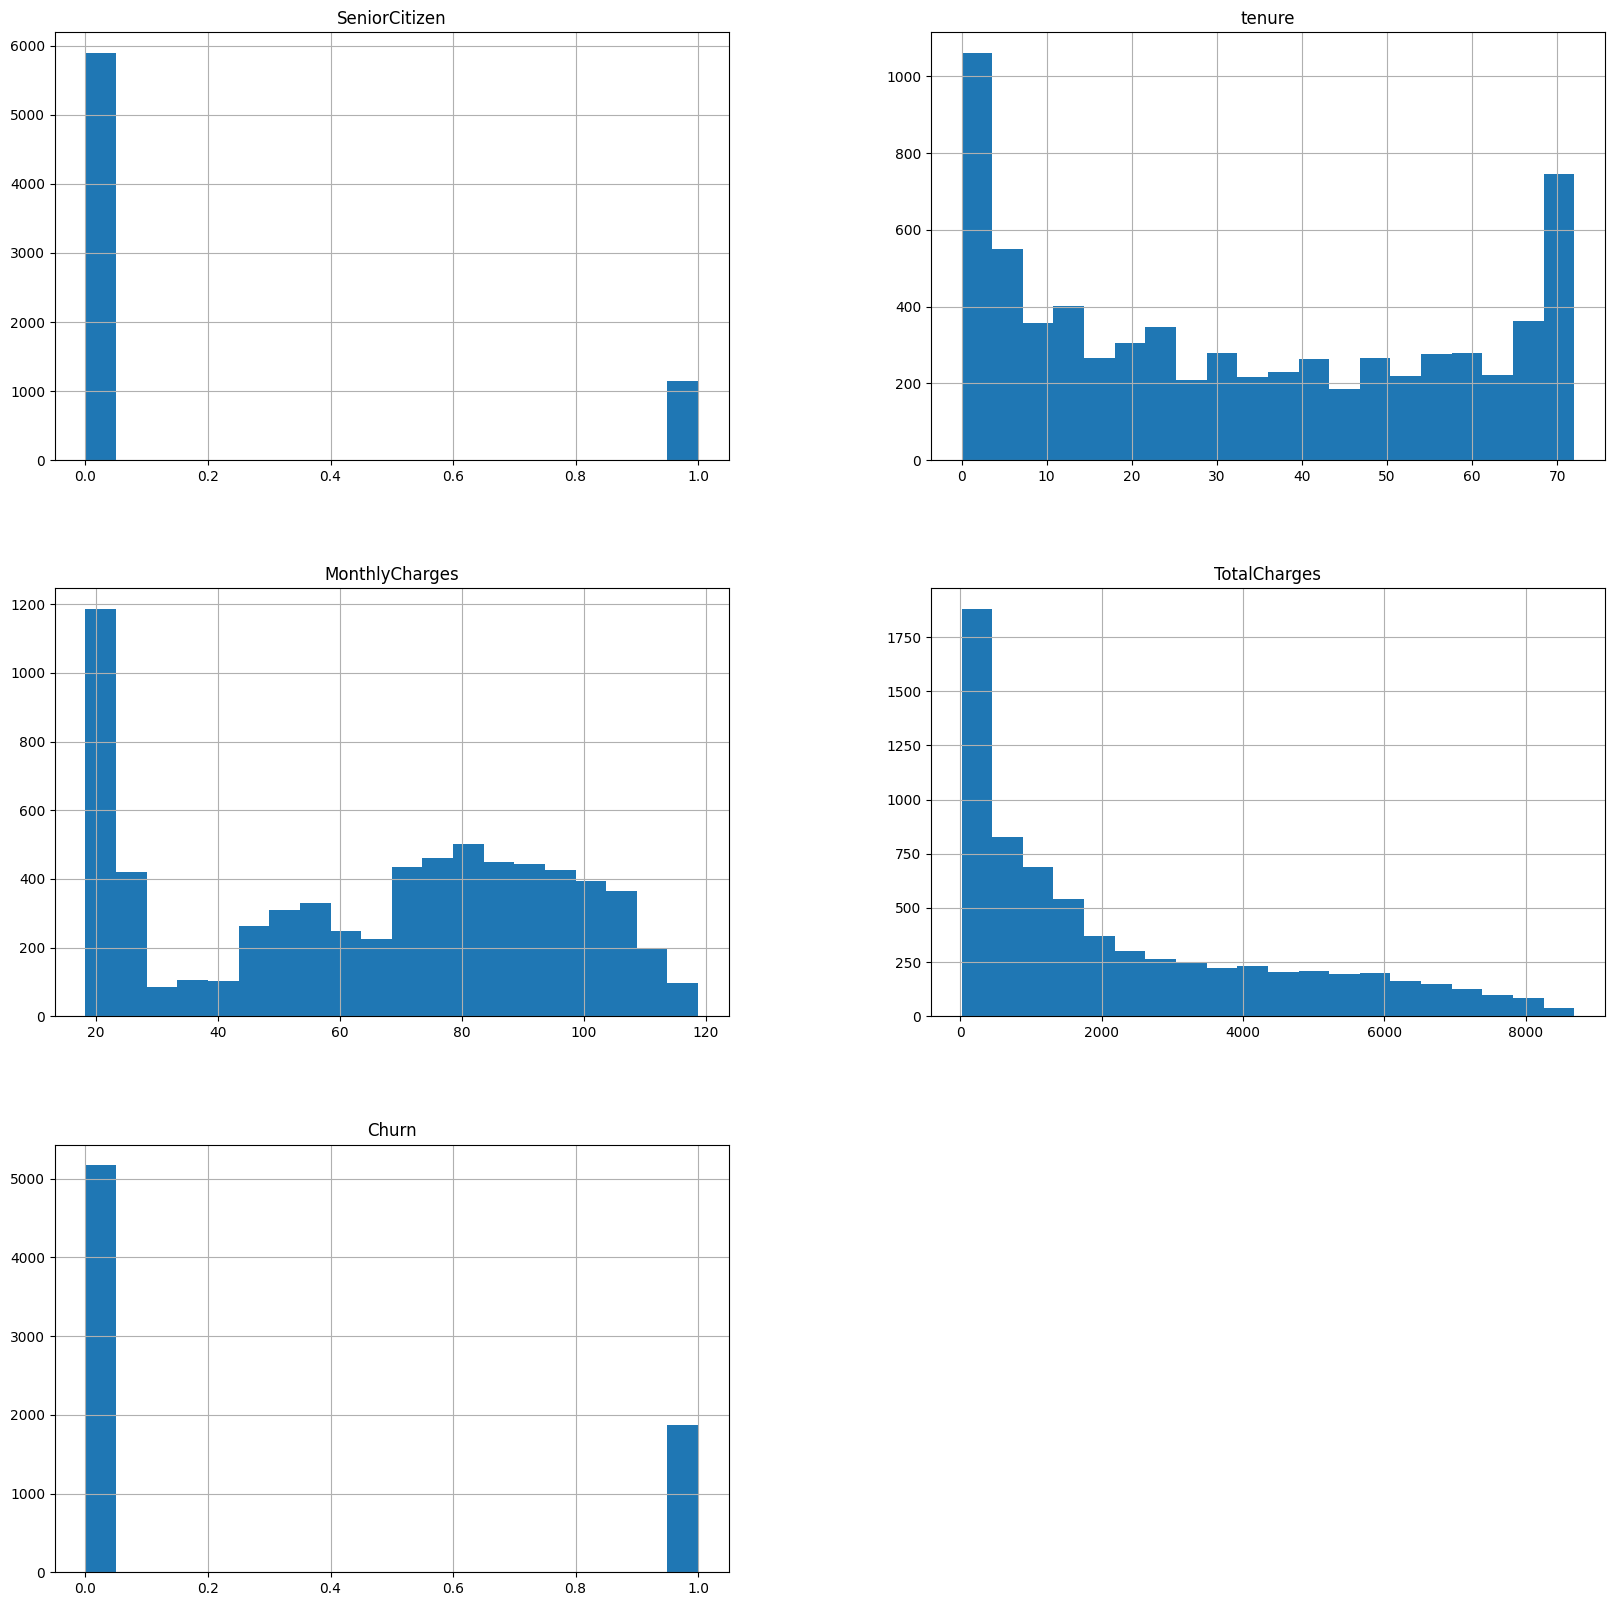

In [41]:
#
num_bins = 20
df.hist(figsize=(20,20), bins=num_bins)
plt.savefig('churn_histogram')
plt.show()

In [42]:
#grab column name
def grab_col_names(dataframe, cat_th=10, car_th=20):
  #cat_cols, cat_but_car
  cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
  #
  num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]
  #
  cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]
  #
  cat_cols = cat_cols + num_but_cat
  cat_cols = [col for col in cat_cols if col not in cat_but_car]
  # num_cols
  num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
  num_cols = [col for col in num_cols if col not in num_but_cat]
  #
  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f'cat_cols: {len(cat_cols)}')
  print(f'num_cols: {len(num_cols)}')
  print(f'cat_but_car: {len(cat_but_car)}')
  print(f'num_but_cat: {len(num_but_cat)}')
  #
  return cat_cols, num_cols, cat_but_car
  #
cat_cols, num_cols, cat_but_car = grab_col_names(df)
#
cat_cols
num_cols

Observations: 7043
Variables: 21
cat_cols: 17
num_cols: 3
cat_but_car: 1
num_but_cat: 2


['tenure', 'MonthlyCharges', 'TotalCharges']

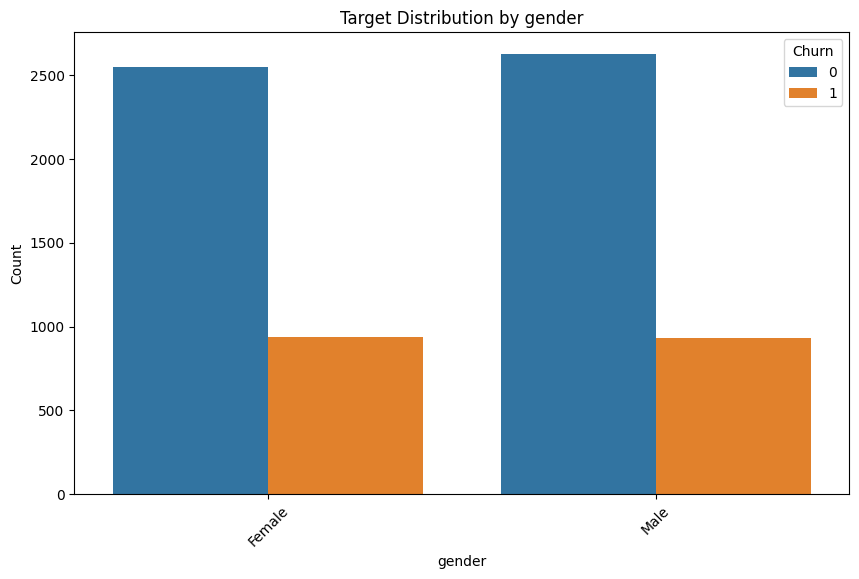

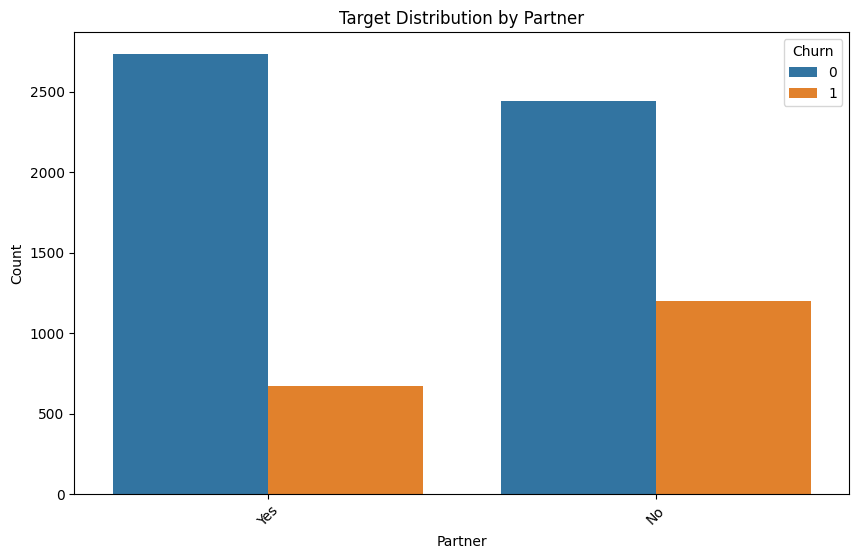

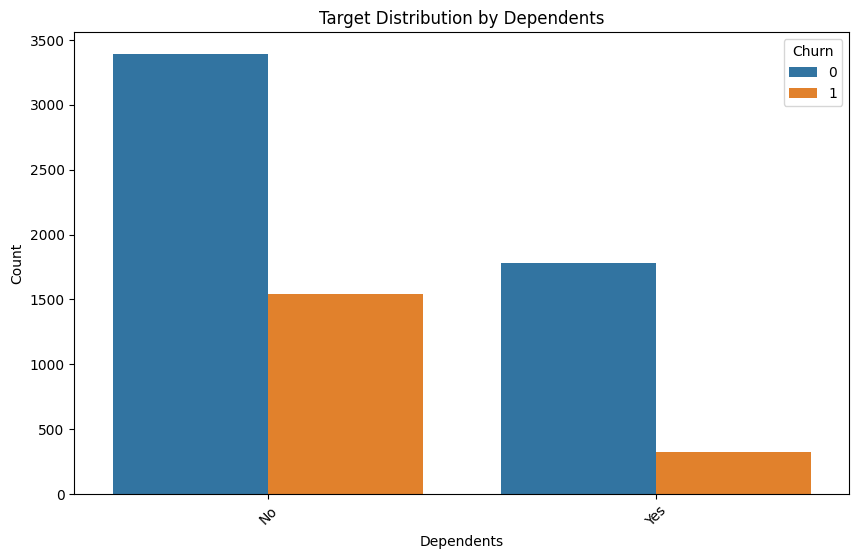

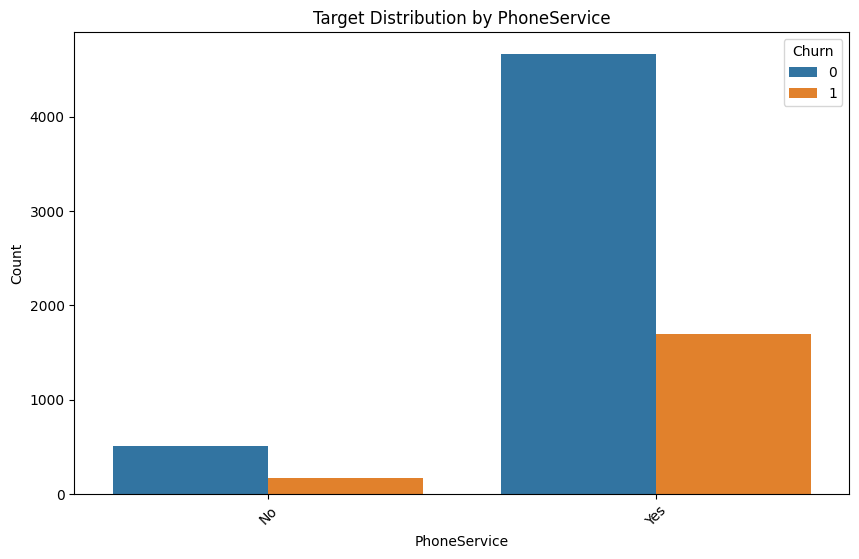

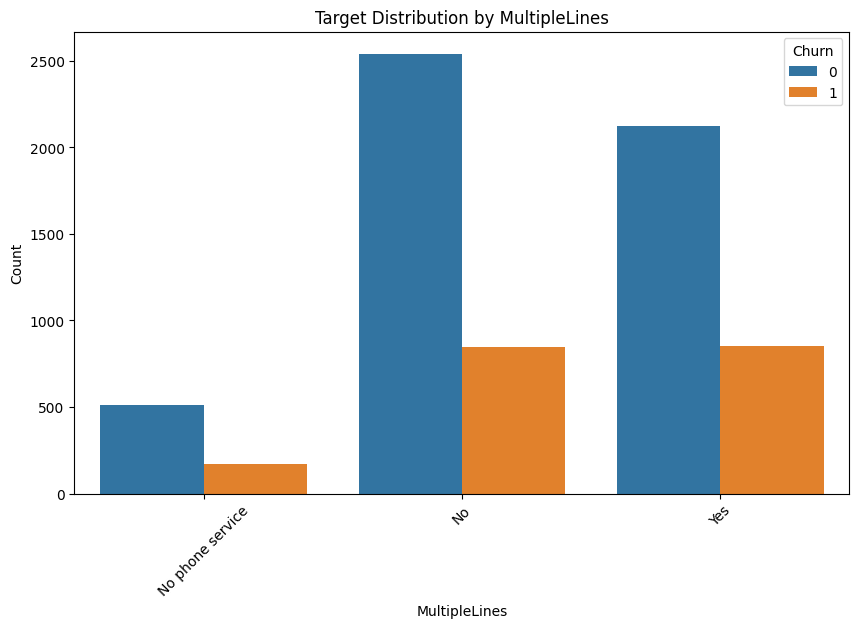

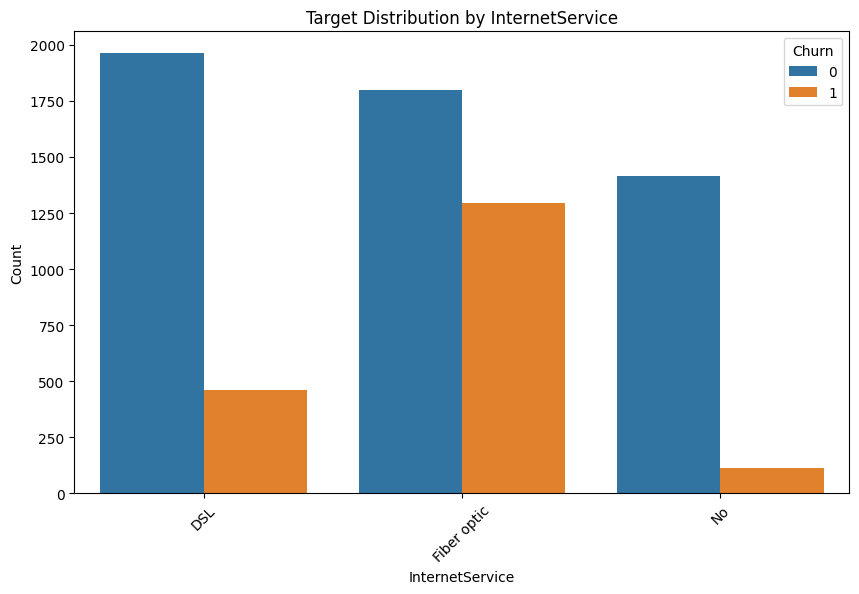

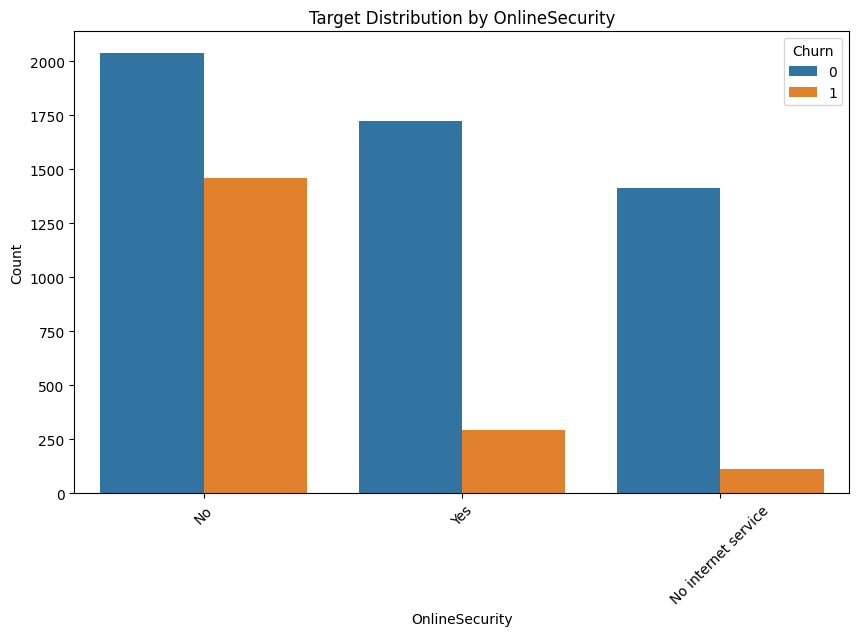

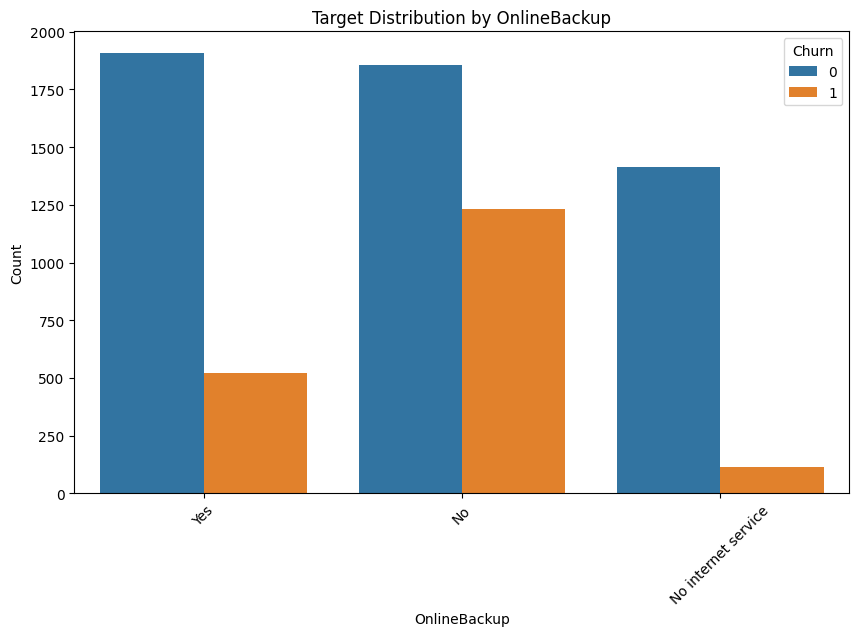

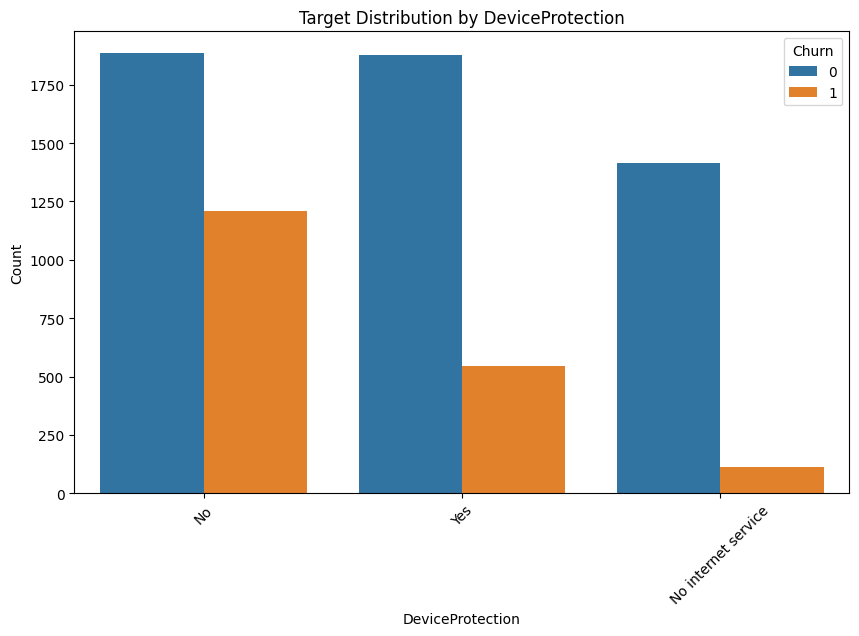

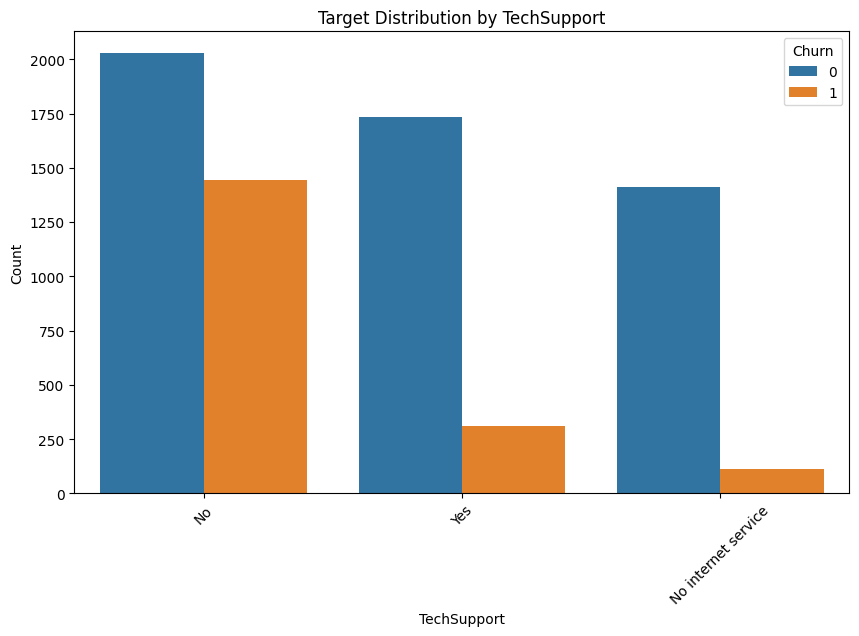

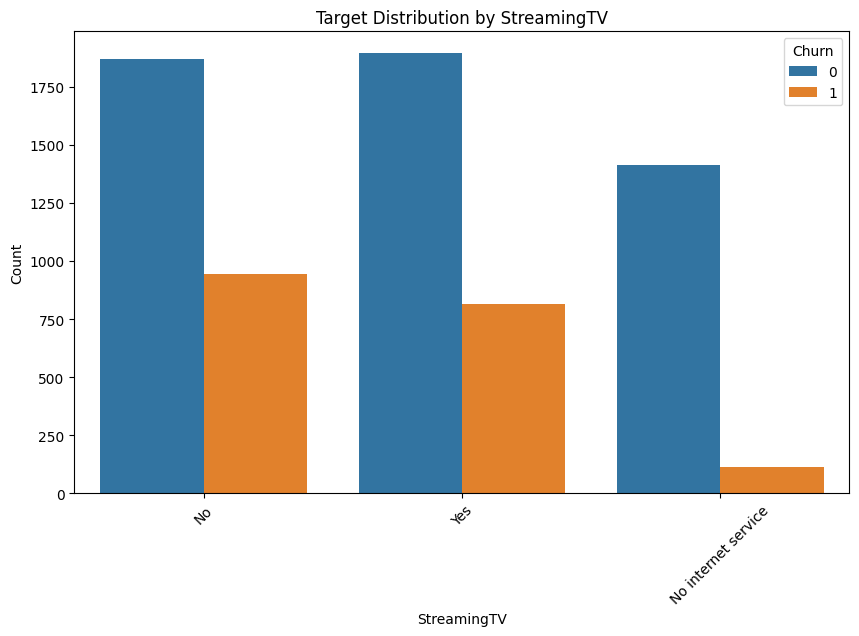

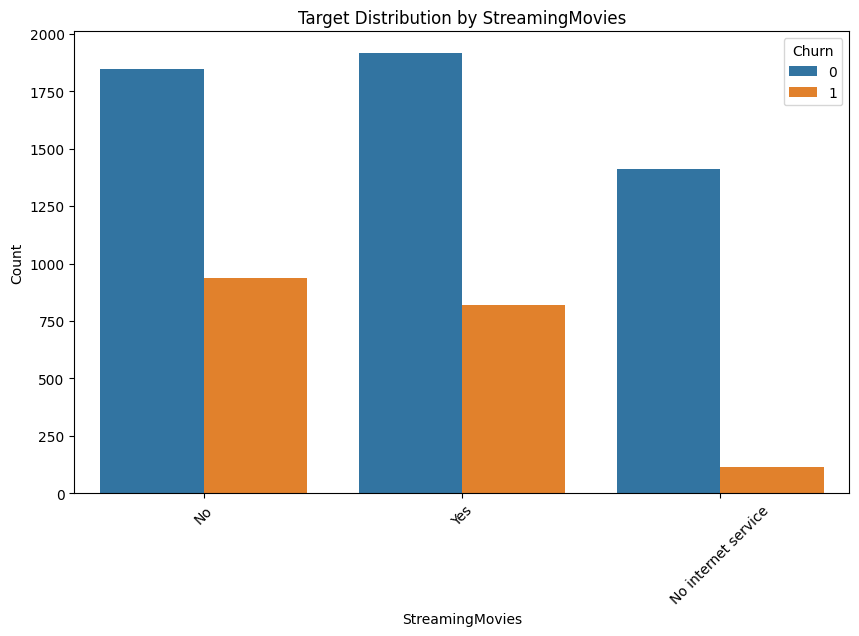

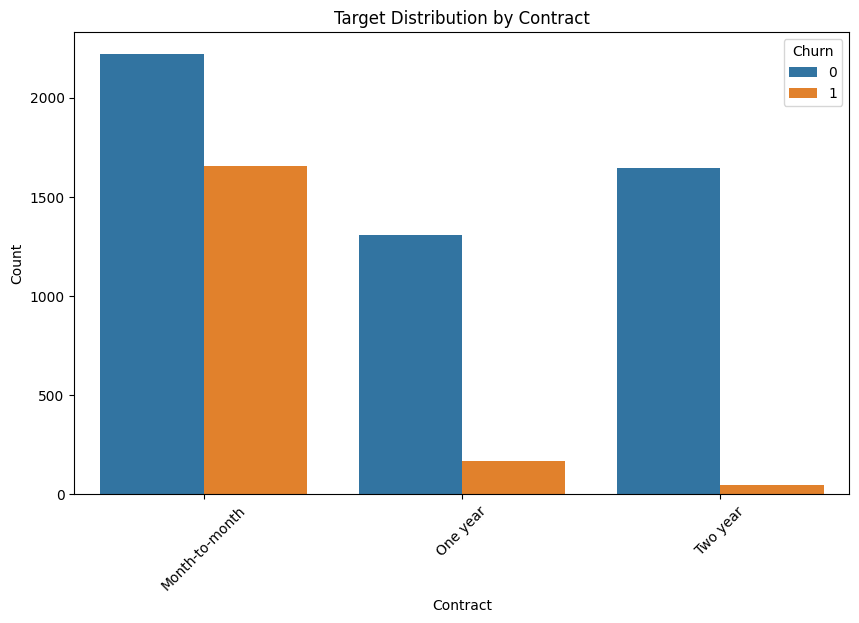

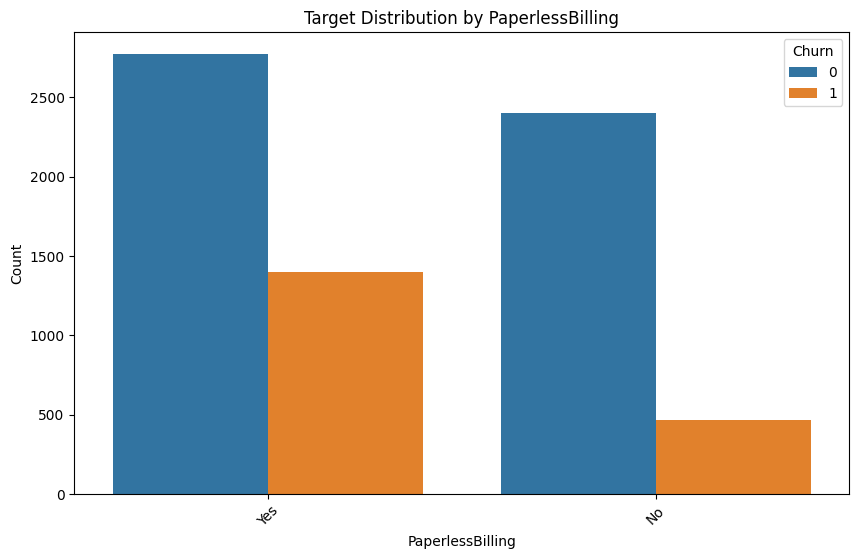

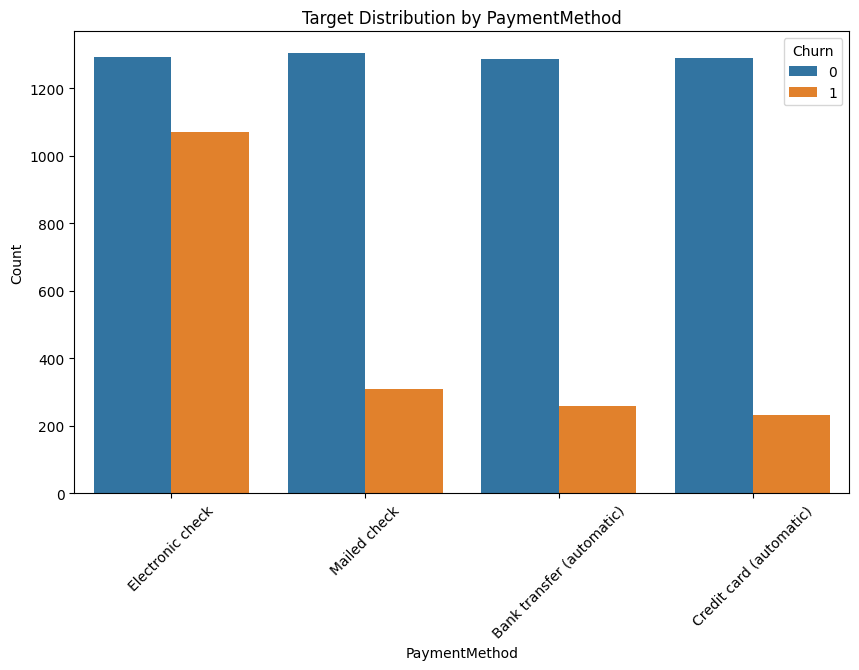

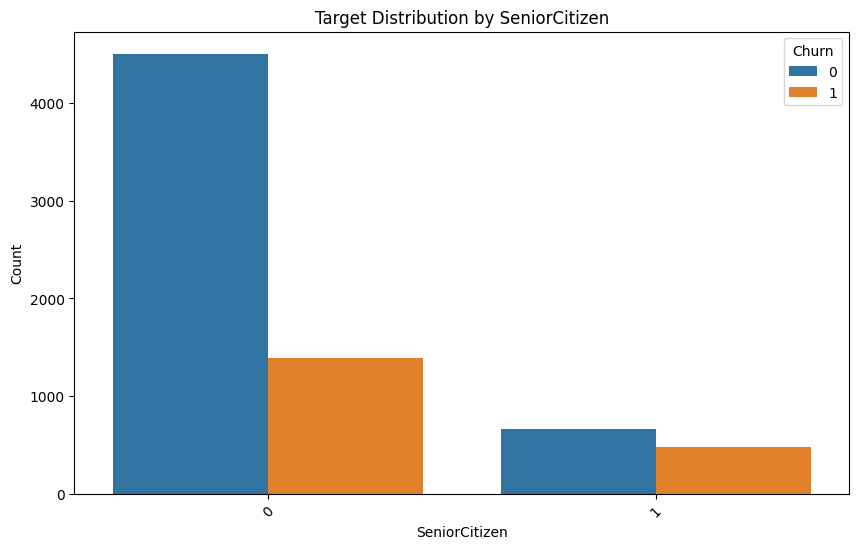

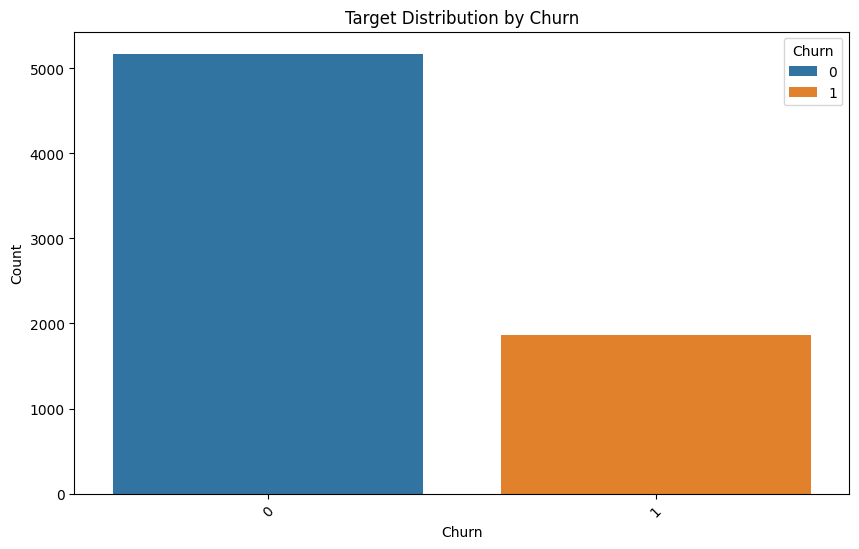

In [43]:
#
def target_vs_category_visualization(dataframe, target, categorical_col):
  #
  plt.figure(figsize=(10, 6))
  sns.countplot(data=dataframe, x=categorical_col, hue=target)
  plt.title(f'Target Distribution by {categorical_col}')
  plt.xlabel(categorical_col)
  plt.ylabel('Count')
  plt.xticks(rotation=45)
  #

for col in cat_cols:
  target_vs_category_visualization(df, 'Churn', col)


In [44]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n")

for col in num_cols:
    target_summary_with_num(df, "Churn", col)

       tenure
Churn        
0      37.570
1      17.979

       MonthlyCharges
Churn                
0              61.265
1              74.441

       TotalCharges
Churn              
0          2555.344
1          1531.796



In [45]:
#
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))


for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

        CHURN_MEAN
gender            
Female       0.269
Male         0.262
         CHURN_MEAN
Partner            
No            0.330
Yes           0.197
            CHURN_MEAN
Dependents            
No               0.313
Yes              0.155
              CHURN_MEAN
PhoneService            
No                 0.249
Yes                0.267
                  CHURN_MEAN
MultipleLines               
No                     0.250
No phone service       0.249
Yes                    0.286
                 CHURN_MEAN
InternetService            
DSL                   0.190
Fiber optic           0.419
No                    0.074
                     CHURN_MEAN
OnlineSecurity                 
No                        0.418
No internet service       0.074
Yes                       0.146
                     CHURN_MEAN
OnlineBackup                   
No                        0.399
No internet service       0.074
Yes                       0.215
                     CHURN_MEAN
DeviceProtectio

In [46]:
#Perform outlier observation analysis.
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, check_outlier(df, col))

tenure False
MonthlyCharges False
TotalCharges False


In [47]:
#perform a missing
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns


missing_values_table(df)

              n_miss  ratio
TotalCharges      11  0.160


In [48]:
#perform the correlation
corr_matrix = df[num_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


In [49]:
df.select_dtypes(include=np.number).corrwith(df["Churn"]).sort_values(ascending=False)

,0
Churn,1.000
MonthlyCharges,0.193
SeniorCitizen,0.151
TotalCharges,-0.199
tenure,-0.352


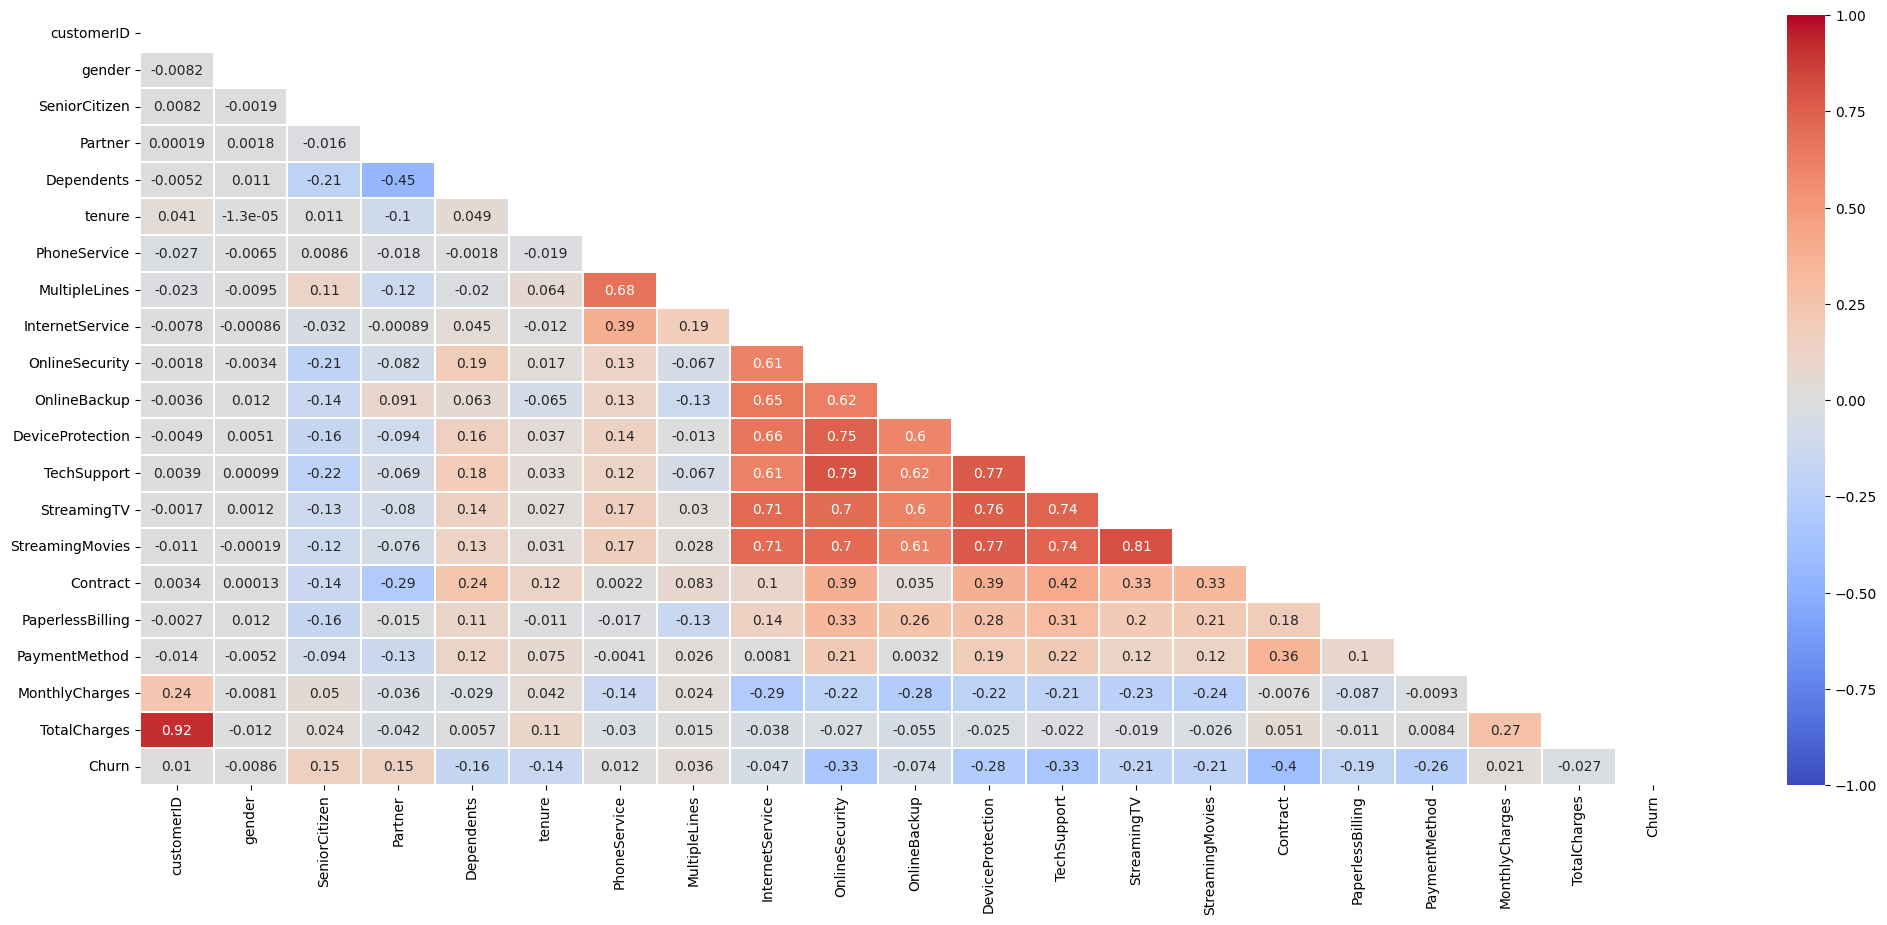

In [50]:
# Correlation between all variables
plt.figure(5, figsize=(25, 10))
corr = df.apply(lambda x: pd.factorize(x)[0]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns,
                 annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

Text(0.5, 1.0, 'Correlation with Churn Rate \n')

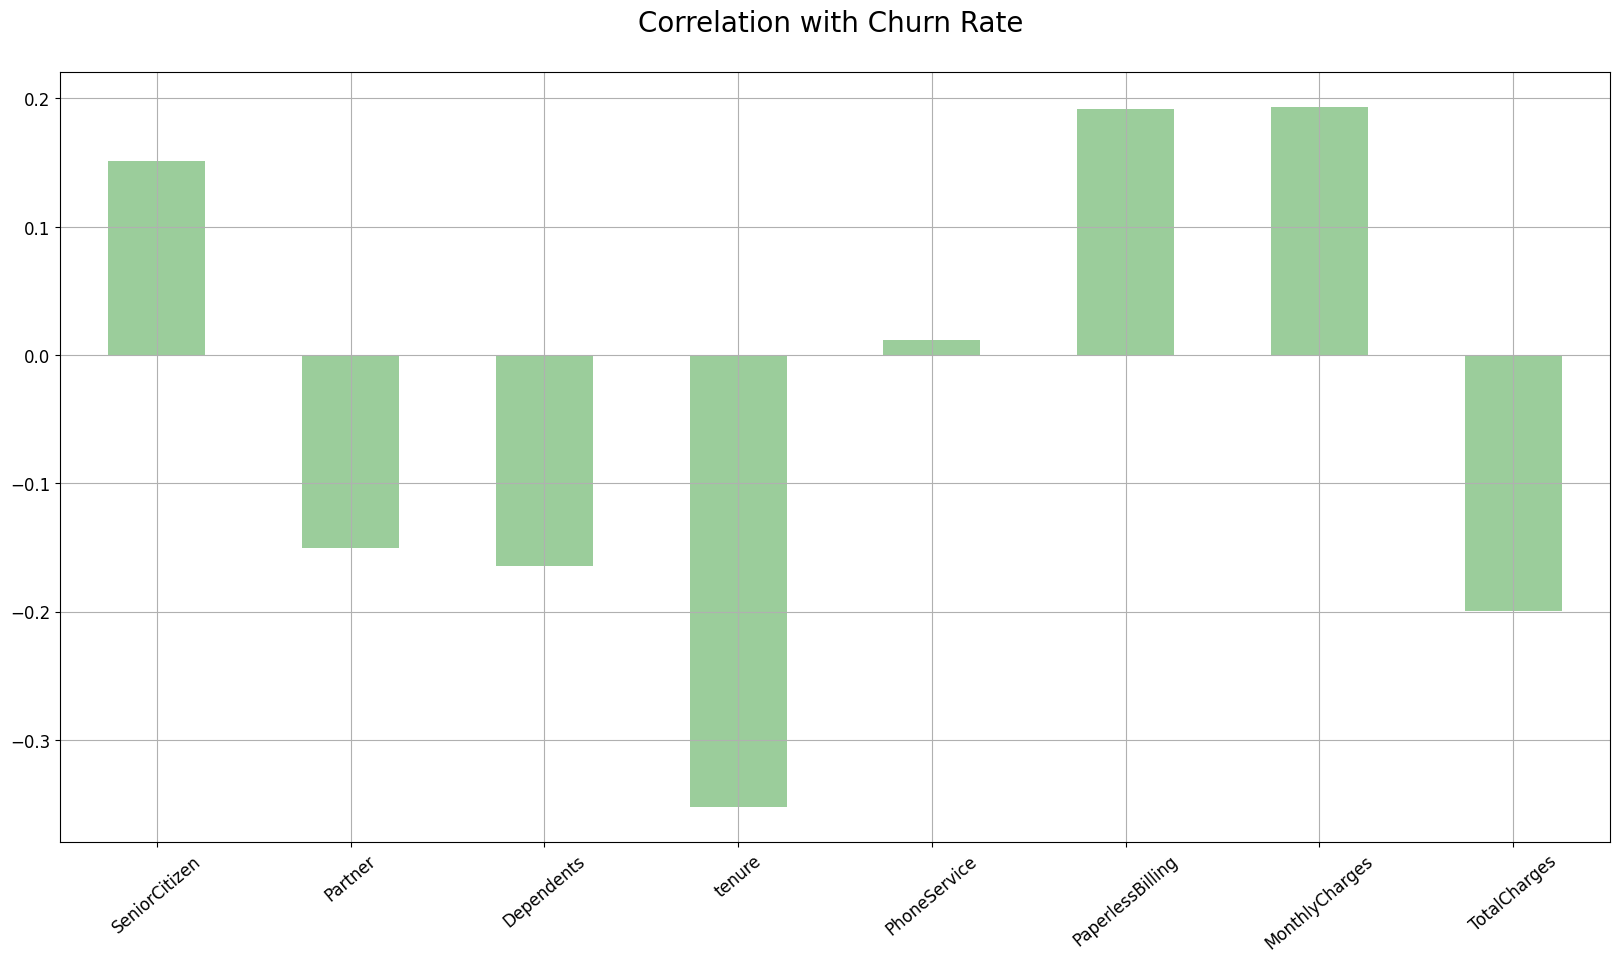

In [51]:
# Correlation between churn and selected boolean and numeric variables
plt.figure()

# Explicitly convert binary categorical columns to numeric (0/1) for correlation
# This addresses the ValueError if these columns were not correctly converted previously.
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

ds_corr = df[['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges']]

correlations = ds_corr.corrwith(df.Churn)
correlations = correlations[correlations!=1]
correlations.plot.bar(
        figsize = (20, 10),
        fontsize = 12,
        color = '#9BCD9B',
        rot = 40, grid = True)

plt.title('Correlation with Churn Rate \n', horizontalalignment="center", fontstyle = "normal", fontsize = "20")

In [52]:
#find na coloumns
na_cols = missing_values_table(df, True)
df.dropna(inplace=True)

              n_miss  ratio
TotalCharges      11  0.160


In [53]:
le = LabelEncoder()

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float]
               and df[col].nunique() == 2]

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in binary_cols:
    df = label_encoder(df, col)

def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 30 >= df[col].nunique() > 2]

df = one_hot_encoder(df, ohe_cols)

In [54]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   object 
 1   gender                                 7032 non-null   int64  
 2   SeniorCitizen                          7032 non-null   int64  
 3   Partner                                7032 non-null   int64  
 4   Dependents                             7032 non-null   int64  
 5   tenure                                 7032 non-null   int64  
 6   PhoneService                           7032 non-null   int64  
 7   PaperlessBilling                       7032 non-null   int64  
 8   MonthlyCharges                         7032 non-null   float64
 9   TotalCharges                           7032 non-null   float64
 10  Churn                                  7032 non-null   int64  
 11  MultipleL

In [55]:
#standardlize for numeric variables
num_cols = [col for col in num_cols if col not in "customerID"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.280,-1.162,-0.994
1,0.064,-0.261,-0.174
2,-1.240,-0.364,-0.960
3,0.512,-0.748,-0.195
4,-1.240,0.196,-0.940


In [56]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.280,0,1,-1.162,-0.994,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,0.064,1,0,-0.261,-0.174,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,-1.240,1,1,-0.364,-0.960,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,0.512,0,0,-0.748,-0.195,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,-1.240,1,1,0.196,-0.940,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [57]:
#using random forest model
y = df['Churn']
X = df.drop(["customerID", "Churn"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy_score(y_pred, y_test)

0.7834123222748816

### 1. Logistic Regression Model

Logistic Regression is a simple yet powerful linear model used for binary classification. It models the probability of a binary outcome. It's often a good baseline model due to its interpretability and efficiency.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=17, solver='liblinear').fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate accuracy
print(f"Logistic Regression Accuracy: {accuracy_score(y_pred_lr, y_test)}")

Logistic Regression Accuracy: 0.8042654028436019


### 2. CatBoost Classifier Model

CatBoost is a high-performance open-source gradient boosting library from Yandex. It's known for its excellent handling of categorical features (often without explicit one-hot encoding, though we've already done some preprocessing here) and robust performance.

In [59]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the CatBoost Classifier model
cb_model = CatBoostClassifier(random_state=17, verbose=0).fit(X_train, y_train)

# Make predictions on the test set
y_pred_cb = cb_model.predict(X_test)

# Evaluate accuracy
print(f"CatBoost Classifier Accuracy: {accuracy_score(y_pred_cb, y_test)}")

CatBoost Classifier Accuracy: 0.8028436018957346


# Task
Introduce the K-Nearest Neighbors (KNN) algorithm for classification tasks. Then, implement the KNN classifier, train it using `X_train` and `y_train`, make predictions on `X_test`, and evaluate its accuracy against `y_test`. Finally, summarize and compare the performance of all implemented models (Random Forest, Logistic Regression, CatBoost, and KNN) based on their accuracies.

## Introduce K-Nearest Neighbors (KNN) Model

### Subtask:
Provide a brief explanation of the K-Nearest Neighbors (KNN) algorithm and its applicability for classification tasks.


### K-Nearest Neighbors (KNN) Algorithm

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm primarily used for classification and regression tasks. It is considered a 'lazy learning' algorithm because it does not construct a general internal model during the training phase. Instead, it memorizes the training dataset and performs computations only when a prediction is requested.

#### How KNN Works for Classification:

1.  **Finding Neighbors**: When a new, unlabeled data point (query point) needs to be classified, KNN identifies the 'k' closest data points (neighbors) to it from the training dataset.

2.  **Distance Metrics**: The 'closeness' between points is typically measured using distance functions. Common distance metrics include:
    *   **Euclidean Distance**: The most frequently used, calculated as the straight-line distance between two points in Euclidean space.
    *   **Manhattan Distance**: The sum of the absolute differences of their Cartesian coordinates.
    *   **Minkowski Distance**: A generalization of Euclidean and Manhattan distances.

3.  **Determining Classification (Majority Vote)**: Once the 'k' nearest neighbors are identified, the algorithm assigns the class label that is most common among these 'k' neighbors to the query point. This is often referred to as a 'majority vote'. For example, if k=5 and three neighbors belong to 'Class A' and two to 'Class B', the query point will be classified as 'Class A'.

#### Key Concepts:

*   **'k' (Number of Neighbors)**: This is a crucial hyperparameter. The choice of 'k' significantly impacts the algorithm's performance. A small 'k' can make the model sensitive to noise and outliers, leading to high variance. A large 'k' can smooth out the decision boundaries, reducing variance but potentially increasing bias by incorporating points from other classes.

*   **Feature Scaling**: KNN is sensitive to the scale of features because distance calculations are affected by feature ranges. Therefore, it's often necessary to normalize or standardize the features before applying KNN.

*   **No Training Phase**: As a lazy learner, KNN does not explicitly learn a model during training. All computation is deferred until prediction time, making it faster to train but potentially slower for predictions on large datasets.

## Train and Evaluate KNN Model

### Subtask:
Implement the K-Nearest Neighbors (KNN) classifier, train it using the training data (`X_train`, `y_train`), make predictions on the test data (`X_test`), and evaluate its accuracy against `y_test`.


**Reasoning**:
To implement the K-Nearest Neighbors (KNN) classifier, I will import the necessary class, instantiate the model, train it on the provided training data, make predictions on the test data, and then evaluate its accuracy.



In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate accuracy
print(f"KNN Classifier Accuracy: {accuracy_score(y_pred_knn, y_test)}")

KNN Classifier Accuracy: 0.7587677725118483


**Reasoning**:
To summarize and compare the performance of all implemented models, I will print the accuracy scores of Random Forest, Logistic Regression, CatBoost, and KNN.



In [63]:
print(f"Random Forest Accuracy: {accuracy_score(y_pred, y_test)}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_pred_lr, y_test)}")
print(f"CatBoost Classifier Accuracy: {accuracy_score(y_pred_cb, y_test)}")
print(f"KNN Classifier Accuracy: {accuracy_score(y_pred_knn, y_test)}")

Random Forest Accuracy: 0.7834123222748816
Logistic Regression Accuracy: 0.8042654028436019
CatBoost Classifier Accuracy: 0.8028436018957346
KNN Classifier Accuracy: 0.7587677725118483


## Final Task

### Subtask:
Summarize the performance of all models implemented (Random Forest, Logistic Regression, CatBoost, and KNN) and provide a comparative overview of their accuracies.


## Summary:

### Q&A
The K-Nearest Neighbors (KNN) model achieved an accuracy of approximately 75.88%. In comparison to the other implemented models:
*   Logistic Regression: 80.43% accuracy
*   CatBoost Classifier: 80.28% accuracy
*   Random Forest: 78.34% accuracy
*   KNN Classifier: 75.88% accuracy

Logistic Regression exhibited the highest accuracy among all models, followed closely by CatBoost. Random Forest performed moderately well, while KNN had the lowest accuracy in this comparison.

### Data Analysis Key Findings
*   The K-Nearest Neighbors (KNN) algorithm is a non-parametric, lazy learning algorithm that classifies new data points based on the majority class of their 'k' nearest neighbors in the training data, using distance metrics like Euclidean distance.
*   The KNN model, when implemented, achieved an accuracy of approximately 75.88% on the test set.
*   Among all evaluated models, Logistic Regression demonstrated the highest accuracy at 80.43%.
*   CatBoost Classifier followed closely with an accuracy of 80.28%.
*   Random Forest Classifier had an accuracy of 78.34%.
*   KNN Classifier performed the lowest among the four models, with an accuracy of 75.88%.

### Insights or Next Steps
*   Given KNN's sensitivity to feature scaling and the 'k' hyperparameter, further optimization, such as feature standardization and hyperparameter tuning for 'k', could potentially improve its performance.
*   Considering Logistic Regression and CatBoost performed best, further analysis could focus on their specific characteristics or ensemble methods combining their strengths to achieve even higher predictive accuracy.


# Task
Introduce the XGBoost algorithm, implement an XGBoost classifier, train it using `X_train` and `y_train`, make predictions on `X_test`, and evaluate its accuracy against `y_test`. Then, summarize the performance of all implemented models (Random Forest, Logistic Regression, CatBoost, KNN, and XGBoost) and provide a comparative overview of their accuracies. Finally, provide a final summary and insights based on the performance of all models.

## Introduce XGBoost Model

### Subtask:
Provide a brief explanation of the XGBoost algorithm and its applicability for classification tasks.


## Introduce XGBoost Model

### Subtask:
Provide a brief explanation of the XGBoost algorithm and its applicability for classification tasks.

### XGBoost (eXtreme Gradient Boosting) Algorithm

XGBoost is an open-source software library that provides an optimized distributed gradient boosting framework. It is designed to be highly efficient, flexible, and portable. At its core, XGBoost implements machine learning algorithms under the gradient boosting framework. Gradient boosting is a powerful ensemble learning technique that builds a strong predictive model by combining multiple weak predictive models, typically decision trees.

#### How XGBoost Works for Classification:

XGBoost operates by sequentially building an ensemble of decision trees. In the context of classification:

1.  **Iterative Model Building**: It starts with an initial prediction (often a simple constant value or a single decision tree). Subsequent decision trees (weak learners) are then added one by one to correct the errors of the previous trees.
2.  **Gradient Boosting**: Each new tree is trained to predict the *residuals* or the errors made by the combination of all previously built trees. This means it focuses on the data points that the previous models struggled with, effectively trying to minimize a loss function (e.g., log-loss for classification).
3.  **Weighted Voting**: The predictions from all individual trees are then summed up to make the final classification decision. XGBoost assigns weights to each tree's prediction, with later trees often having a stronger influence as they learn from previous mistakes.
4.  **Decision Trees as Weak Learners**: XGBoost typically uses classification and regression trees (CARTs) as its weak learners. These trees decide how to split the data based on features to optimize the reduction of the loss function.

#### Key Features and Advantages of XGBoost:

XGBoost has gained immense popularity due to several key features:

*   **Efficiency and Speed**: It is highly optimized for performance, with parallel processing capabilities, tree pruning, and cache-aware access, making it significantly faster than traditional gradient boosting implementations.
*   **Scalability**: It is designed to be highly scalable, working efficiently on large datasets and distributed computing environments.
*   **Handling Missing Values**: XGBoost has an inbuilt mechanism to handle missing values. It learns the best direction (left or right split) for nodes with missing values from the data itself, rather than requiring explicit imputation.
*   **Regularization Techniques**: To prevent overfitting, XGBoost incorporates both L1 (Lasso) and L2 (Ridge) regularization terms into its objective function. This helps in controlling the complexity of the trees and making the model more robust.
*   **Flexibility**: Users can define custom optimization objectives and evaluation metrics, providing great flexibility for different problem types.
*   **Feature Importance**: It can automatically calculate and rank feature importance, which is valuable for feature selection and model interpretability.

## Train and Evaluate XGBoost Model

### Subtask:
Implement the XGBoost classifier, train it using the training data (`X_train`, `y_train`), make predictions on the test data (`X_test`), and evaluate its accuracy against `y_test`.


**Reasoning**:
To implement the XGBoost classifier, I will import the necessary class, instantiate the model, train it on the provided training data, make predictions on the test data, and then evaluate its accuracy.



In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=17).fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate accuracy
print(f"XGBoost Classifier Accuracy: {accuracy_score(y_pred_xgb, y_test)}")

XGBoost Classifier Accuracy: 0.7824644549763033


**Reasoning**:
To summarize and compare the performance of all implemented models, I will print the accuracy scores of Random Forest, Logistic Regression, CatBoost, KNN, and XGBoost.



In [65]:
print(f"Random Forest Accuracy: {accuracy_score(y_pred, y_test)}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_pred_lr, y_test)}")
print(f"CatBoost Classifier Accuracy: {accuracy_score(y_pred_cb, y_test)}")
print(f"KNN Classifier Accuracy: {accuracy_score(y_pred_knn, y_test)}")
print(f"XGBoost Classifier Accuracy: {accuracy_score(y_pred_xgb, y_test)}")

Random Forest Accuracy: 0.7834123222748816
Logistic Regression Accuracy: 0.8042654028436019
CatBoost Classifier Accuracy: 0.8028436018957346
KNN Classifier Accuracy: 0.7587677725118483
XGBoost Classifier Accuracy: 0.7824644549763033


## Final Task

### Subtask:
Summarize the performance of all models implemented (Random Forest, Logistic Regression, CatBoost, KNN, and XGBoost) and provide a comparative overview of their accuracies. Finally, provide a final summary and insights based on the performance of all models.

## Summary:

The XGBoost model achieved an accuracy of approximately 78.25%. Here's a comparative overview of all implemented models:
*   Logistic Regression: 80.43% accuracy
*   CatBoost Classifier: 80.28% accuracy
*   Random Forest: 78.34% accuracy
*   XGBoost Classifier: 78.25% accuracy
*   KNN Classifier: 75.88% accuracy

Logistic Regression exhibited the highest accuracy among all models, closely followed by CatBoost. Random Forest and XGBoost performed similarly, both achieving accuracies around 78%. KNN had the lowest accuracy in this comparison.

### Data Analysis Key Findings
*   The K-Nearest Neighbors (KNN) algorithm is a non-parametric, lazy learning algorithm that classifies new data points based on the majority class of their 'k' nearest neighbors in the training data, using distance metrics like Euclidean distance.
*   The KNN model achieved an accuracy of approximately 75.88% on the test set.
*   XGBoost is an optimized distributed gradient boosting framework, known for its efficiency, scalability, and regularization capabilities. The XGBoost model achieved an accuracy of approximately 78.25%.
*   Among all evaluated models, Logistic Regression demonstrated the highest accuracy at 80.43%.
*   CatBoost Classifier followed closely with an accuracy of 80.28%.
*   Random Forest Classifier had an accuracy of 78.34%.
*   KNN Classifier performed the lowest among the five models, with an accuracy of 75.88%.

### Insights or Next Steps
*   Logistic Regression and CatBoost were the top performers, suggesting that simpler models or models specifically designed for categorical features (like CatBoost) are effective for this dataset.
*   The similar performance of Random Forest and XGBoost indicates that ensemble tree-based methods provide a competitive but not necessarily superior performance compared to the top two in this specific case.
*   Further hyperparameter tuning for all models, especially for KNN (optimizing 'k' and distance metrics) and the tree-based models (Random Forest, CatBoost, XGBoost for parameters like `n_estimators`, `max_depth`, `learning_rate`), could potentially yield better results.
*   Exploring other evaluation metrics beyond accuracy, such as precision, recall, F1-score, and ROC AUC, would provide a more comprehensive understanding of each model's performance, especially given the potential class imbalance in churn prediction.
*   Feature engineering based on domain knowledge could also improve model performance significantly.

## Final Task

### Subtask:
Provide a final summary and insights based on the performance of all models.


## Summary:

### Q&A
The performance of all implemented models can be summarized as follows:
*   **Logistic Regression**: Achieved the highest accuracy at 80.43%.
*   **CatBoost Classifier**: Followed closely with an accuracy of 80.28%.
*   **Random Forest Classifier**: Recorded an accuracy of 78.34%.
*   **XGBoost Classifier**: Performed similarly to Random Forest, with an accuracy of 78.25%.
*   **KNN Classifier**: Had the lowest accuracy among all models, at 75.88%.

### Data Analysis Key Findings
*   The XGBoost model, an optimized distributed gradient boosting framework, was implemented and achieved an accuracy of approximately 78.25% on the test set.
*   Among the five models evaluated, Logistic Regression was the top performer with an accuracy of 80.43%.
*   CatBoost Classifier secured the second-highest accuracy at 80.28%.
*   Random Forest and XGBoost classifiers demonstrated similar performance, with accuracies around 78.34% and 78.25% respectively.
*   The K-Nearest Neighbors (KNN) model showed the lowest performance, with an accuracy of 75.88%.

### Insights or Next Steps
*   The superior performance of Logistic Regression and CatBoost suggests that these models, possibly due to their underlying mechanisms (simplicity or handling of categorical features), are well-suited for this specific dataset.
*   Future work should involve thorough hyperparameter tuning for all models, particularly for KNN (optimizing 'k' and distance metrics) and the tree-based models (Random Forest, CatBoost, XGBoost), to potentially enhance their performance.
*   To gain a more comprehensive understanding of model efficacy, it is recommended to evaluate models using a wider range of metrics beyond accuracy, such as precision, recall, F1-score, and ROC AUC, which can be particularly insightful in cases of class imbalance.
